# Multi-branch MLP regressor - intermediate integration

This notebook implements a multi-branch MLP regressor using the intermediate integration approach. In this approach, each input modality is processed through its own branch of the network, and the outputs of these branches are concatenated and passed through additional layers to produce the final output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import pyarrow
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from itertools import product
from captum.attr import DeepLiftShap

c:\Users\joddy\repos\multiomics_integration_publication\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_root = Path.cwd().parent
print(project_root)

c:\Users\joddy\repos\multiomics_integration_publication


## Data processing

In [3]:
# import pre-processed data
lcms_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' / 'lcms_data_modelling.feather')
miRNA_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' /  'mirna_data_modelling.feather')
olink_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' / 'olink_data_modelling.feather')
scRNA_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' /  'scRNA_modelling_data.feather')
combined_metadata = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'combined_metadata.feather')
nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_proportions_run_4.csv')

In [4]:
# Extract vessel and day numbers
nk_cell_proportions[['vessel', 'day']] = nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
nk_cell_proportions['vessel'] = pd.to_numeric(nk_cell_proportions['vessel'])
nk_cell_proportions['day'] = pd.to_numeric(nk_cell_proportions['day'])
nk_cell_proportions['label'] = 'r4_v' + nk_cell_proportions['vessel'].astype(str) + '_d' + nk_cell_proportions['day'].astype(str)

In [5]:
# Set index to 'label' and drop the column for all modalities
miRNA_data.index = miRNA_data['label']
miRNA_data = miRNA_data.drop(columns=['label'])

olink_data.index = olink_data['label']
olink_data = olink_data.drop(columns=['label'])

scRNA_data.index = scRNA_data['label']
scRNA_data = scRNA_data.drop(columns=['label'])

lcms_data.index = lcms_data['label']
lcms_data = lcms_data.drop(columns=['label'])

target_variable = nk_cell_proportions[['proportion_NK', 'label']]
target_variable.index = target_variable['label']
target_variable = target_variable.drop(columns=['label'])

# Sort all omics data by their index in alphanumeric order
scRNA_data = scRNA_data.sort_index()
olink_data = olink_data.sort_index()
miRNA_data = miRNA_data.sort_index()
lcms_data = lcms_data.sort_index()
target_variable = target_variable.sort_index()

# check that the indexes match up
print(olink_data.index.equals(target_variable.index))
print(scRNA_data.index.equals(target_variable.index))
print(miRNA_data.index.equals(target_variable.index))
print(lcms_data.index.equals(target_variable.index))

False
True
False
False


## Multi-branch MLP regressor

In [6]:
modalities = [miRNA_data, olink_data, scRNA_data, lcms_data]
target = target_variable['proportion_NK']

# Align sample IDs across all modalities and target (union of all sample IDs)
all_ids = sorted(set().union(*[df.index for df in modalities], target.index))
modality_matrices, modality_masks = [], []

for df in modalities:
    df_aligned = df.reindex(all_ids).fillna(0.0)
    mask = (~df.reindex(all_ids).isna()).astype(float).values
    modality_matrices.append(torch.tensor(df_aligned.values, dtype=torch.float32))
    modality_masks.append(torch.tensor(mask, dtype=torch.float32))

target_aligned = target.reindex(all_ids).values.astype(np.float32)
target_tensor = torch.tensor(target_aligned, dtype=torch.float32)

In [7]:
class MaskedBranch(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        # Input dimension doubles because we append the mask
        self.net = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x, mask):
        # Concatenate feature values and mask
        x_masked = torch.cat([x, mask], dim=1)
        return self.net(x_masked)

class MultiBranchMLP(nn.Module):
    def __init__(self, input_dims, hidden_dim=64, final_hidden=64, min_branch_hidden=8):
        super().__init__()

        # Compute average number of features across branches
        avg_features = np.mean(input_dims)

        # Compute hidden size for each branch proportional to number of features
        branch_hidden_dims = [
            max(int(hidden_dim * d / avg_features), min_branch_hidden) 
            for d in input_dims
        ]

        # Create branches
        self.branches = nn.ModuleList([
            MaskedBranch(d, h) for d, h in zip(input_dims, branch_hidden_dims)
        ])

        # Final fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(sum(branch_hidden_dims), final_hidden),
            nn.ReLU(),
            nn.Linear(final_hidden, 1)
        )

    def forward(self, Xs, Masks):
        branch_outs = [branch(x, m) for branch, x, m in zip(self.branches, Xs, Masks)]
        combined = torch.cat(branch_outs, dim=1)
        return self.fc(combined).squeeze(1)


# Nested cross-validation

In [8]:
def train_one_fold(model, optimizer, criterion, Xs_train, Ms_train, y_train, Xs_val, Ms_val, y_val, num_epochs=100, device='cpu'):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(Xs_train, Ms_train)
        loss = criterion(y_pred_train, y_train)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_val = model(Xs_val, Ms_val).cpu().numpy()
        y_true_val = y_val.cpu().numpy()

    r2 = r2_score(y_true_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
    return r2, rmse

In [9]:
# ==== Nested Cross-Validation ====
def nested_cv(modality_matrices, modality_masks, target_tensor, outer_splits=5, inner_splits=3, device='cpu'):
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=42)
    results = []
    trained_models = [] 

    # Hyperparameter grid
    lr_options = [1e-2, 1e-3, 1e-4]
    hidden_options = [32, 64, 128]
    final_hidden_options = [32, 64, 128]
    param_grid = list(product(lr_options, hidden_options, final_hidden_options))

    for train_idx, test_idx in outer_cv.split(target_tensor):
        # Outer training/test split
        Xs_train_outer = [X[train_idx] for X in modality_matrices]
        Ms_train_outer = [M[train_idx] for M in modality_masks]
        y_train_outer = target_tensor[train_idx]

        Xs_test_outer = [X[test_idx] for X in modality_matrices]
        Ms_test_outer = [M[test_idx] for M in modality_masks]
        y_test_outer = target_tensor[test_idx]

        # === Inner CV to select best hyperparameters ===
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)
        best_score, best_params = -np.inf, None

        for lr, hidden_dim, final_hidden in param_grid:
            inner_scores = []
            for inner_train_idx, val_idx in inner_cv.split(y_train_outer):
                # Inner training/validation split
                Xs_inner_train = [X[inner_train_idx].to(device) for X in Xs_train_outer]
                Ms_inner_train = [M[inner_train_idx].to(device) for M in Ms_train_outer]
                y_inner_train = y_train_outer[inner_train_idx].to(device)

                Xs_val = [X[val_idx].to(device) for X in Xs_train_outer]
                Ms_val = [M[val_idx].to(device) for M in Ms_train_outer]
                y_val = y_train_outer[val_idx].to(device)

                # Create model & optimizer
                model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
                optimizer = optim.Adam(model.parameters(), lr=lr)
                criterion = nn.MSELoss()

                r2, _ = train_one_fold(model, optimizer, criterion, Xs_inner_train, Ms_inner_train, y_inner_train, Xs_val, Ms_val, y_val, num_epochs=50, device=device)
                inner_scores.append(r2)

            avg_inner_score = np.mean(inner_scores)
            if avg_inner_score > best_score:
                best_score = avg_inner_score
                best_params = (lr, hidden_dim, final_hidden)

        # === Train with best hyperparameters on full outer training set ===
        lr, hidden_dim, final_hidden = best_params
        model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        Xs_train_full = [X.to(device) for X in Xs_train_outer]
        Ms_train_full = [M.to(device) for M in Ms_train_outer]
        y_train_full = y_train_outer.to(device)

        Xs_test_full = [X.to(device) for X in Xs_test_outer]
        Ms_test_full = [M.to(device) for M in Ms_test_outer]
        y_test_full = y_test_outer.to(device)

        r2, rmse = train_one_fold(model, optimizer, criterion, Xs_train_full, Ms_train_full, y_train_full, Xs_test_full, Ms_test_full, y_test_full, num_epochs=100, device=device)
        results.append((best_params, r2, rmse))

        trained_models.append(model)

        print(f"Outer Fold Done. Best Params={best_params}, Test R2={r2:.3f}, RMSE={rmse:.3f}")

    return results

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
results = nested_cv(modality_matrices, modality_masks, target_tensor, outer_splits=5, inner_splits=3, device=device)
print("Final Nested CV Results:", results)

Outer Fold Done. Best Params=(0.0001, 32, 32), Test R2=0.941, RMSE=0.058
Outer Fold Done. Best Params=(0.0001, 128, 32), Test R2=0.995, RMSE=0.022
Outer Fold Done. Best Params=(0.001, 32, 64), Test R2=0.950, RMSE=0.049
Outer Fold Done. Best Params=(0.0001, 32, 32), Test R2=0.956, RMSE=0.068
Outer Fold Done. Best Params=(0.0001, 64, 64), Test R2=0.972, RMSE=0.026
Final Nested CV Results: [((0.0001, 32, 32), 0.9407036900520325, 0.05761219463698365), ((0.0001, 128, 32), 0.9954158663749695, 0.02215091137298724), ((0.001, 32, 64), 0.9503187537193298, 0.04872437899652779), ((0.0001, 32, 32), 0.9564152359962463, 0.06848728270649403), ((0.0001, 64, 64), 0.9719712734222412, 0.025620626910173548)]


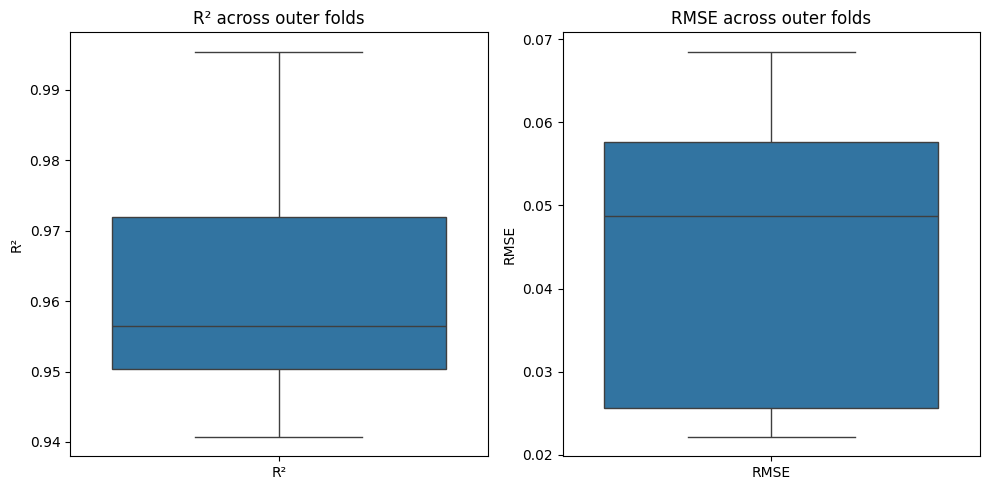

In [11]:
# Extract metrics
r2_scores = [r2 for _, r2, _ in results]
rmse_scores = [rmse for _, _, rmse in results]

# Set up figure
plt.figure(figsize=(10, 5))

# R² boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=r2_scores)
plt.title("R² across outer folds")
plt.ylabel("R²")
plt.xticks([0], ["R²"])

# RMSE boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=rmse_scores)
plt.title("RMSE across outer folds")
plt.ylabel("RMSE")
plt.xticks([0], ["RMSE"])

plt.tight_layout()
plt.show()

# SHAP values

Compputed at the branch level.

In [12]:
device = 'cpu'  # or 'cuda' if available

# === Hyperparameter grid ===
lr_options = [1e-2, 1e-3, 1e-4]
hidden_options = [32, 64, 128]
final_hidden_options = [32, 64, 128]
param_grid = list(product(lr_options, hidden_options, final_hidden_options))

num_epochs = 100
cv_splits = 5

# === K-fold CV for hyperparameter tuning ===
kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
best_score, best_params = -np.inf, None

for lr, hidden_dim, final_hidden in param_grid:
    fold_scores = []

    for train_idx, val_idx in kf.split(target_tensor):
        # Prepare fold data
        Xs_train = [X[train_idx].to(device) for X in modality_matrices]
        Ms_train = [M[train_idx].to(device) for M in modality_masks]
        y_train = target_tensor[train_idx].to(device)

        Xs_val = [X[val_idx].to(device) for X in modality_matrices]
        Ms_val = [M[val_idx].to(device) for M in modality_masks]
        y_val = target_tensor[val_idx].to(device)

        # Create model & optimizer
        model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()

        # Train
        model.to(device)
        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            y_pred_train = model(Xs_train, Ms_train)
            loss = criterion(y_pred_train, y_train)
            loss.backward()
            optimizer.step()

        # Validate
        model.eval()
        with torch.no_grad():
            y_pred_val = model(Xs_val, Ms_val).cpu().numpy()
            y_true_val = y_val.cpu().numpy()
            r2 = r2_score(y_true_val, y_pred_val)
        fold_scores.append(r2)

    avg_score = np.mean(fold_scores)
    if avg_score > best_score:
        best_score = avg_score
        best_params = (lr, hidden_dim, final_hidden)

print(f"Best hyperparameters: lr={best_params[0]}, hidden_dim={best_params[1]}, final_hidden={best_params[2]}, CV R²={best_score:.3f}")

# === Train final model on all data with best hyperparameters ===
lr, hidden_dim, final_hidden = best_params
model = MultiBranchMLP([X.shape[1] for X in modality_matrices], hidden_dim=hidden_dim, final_hidden=final_hidden)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

Xs_full = [X.to(device) for X in modality_matrices]
Ms_full = [M.to(device) for M in modality_masks]
y_full = target_tensor.to(device)

model.to(device)
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(Xs_full, Ms_full)
    loss = criterion(y_pred_train, y_full)
    loss.backward()
    optimizer.step()

print("Final model trained on all data.")

Best hyperparameters: lr=0.0001, hidden_dim=32, final_hidden=32, CV R²=0.979
Final model trained on all data.


In [13]:
# === Compute DeepSHAP feature importances ===
model.eval()
all_feature_importances = []

for branch_idx, branch in enumerate(model.branches):
    # Separate feature and mask inputs for this branch
    x_input = Xs_full[branch_idx]
    m_input = Ms_full[branch_idx]

    # Prepare baseline for features (all zeros)
    baseline = torch.zeros_like(x_input)

    # Wrap branch so Captum gets a single-output forward
    class BranchWrapper(torch.nn.Module):
        def __init__(self, branch):
            super().__init__()
            self.branch = branch

        def forward(self, x, mask):
            out = self.branch(x, mask)
            if isinstance(out, tuple):
                out = out[0]
            return out

    branch_wrapper = BranchWrapper(branch)
    branch_wrapper.eval()

    # Initialize DeepLiftShap explainer
    explainer = DeepLiftShap(branch_wrapper)

    # Compute attributions
    attributions = explainer.attribute(
        inputs=(x_input, m_input),
        baselines=(baseline, m_input),
        target=0
    )

    # Only take attributions for features, not mask
    attr_np = attributions[0].detach().cpu().numpy()
    feature_importance = np.mean(np.abs(attr_np), axis=0)
    all_feature_importances.append(feature_importance)

c:\Users\joddy\repos\multiomics_integration_publication\.venv\lib\site-packages\captum\attr\_core\deep_lift.py:810: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


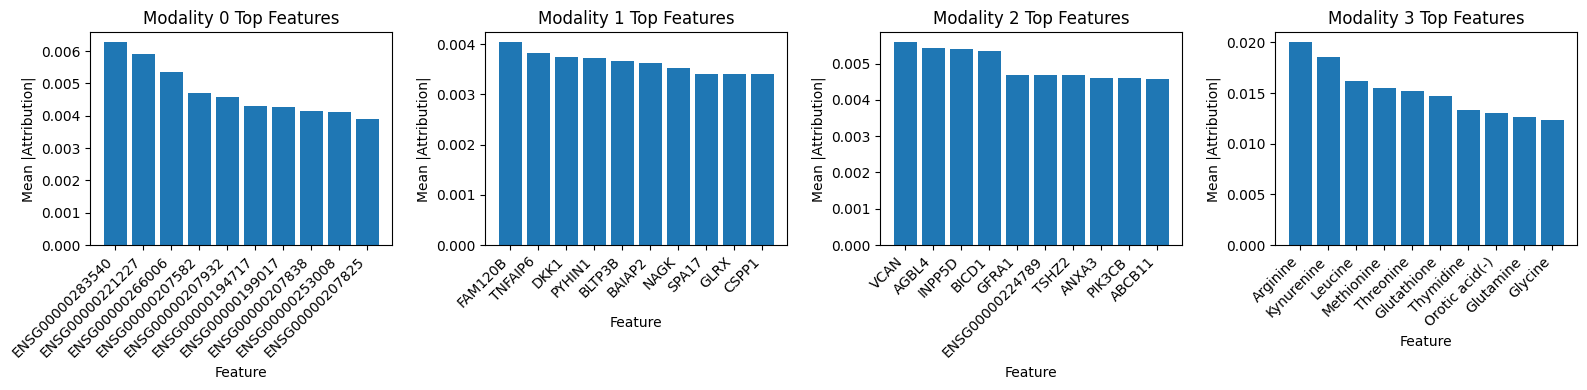

In [14]:
modality_feature_names = [
    list(miRNA_data.columns),
    list(olink_data.columns),
    list(scRNA_data.columns),
    list(lcms_data.columns)
]

modality_names = ["miRNA", "Olink", "scRNA", "LCMS"]

# === Plot top 10 features per modality ===
num_modalities = len(model.branches)
plt.figure(figsize=(4*num_modalities, 4))

for i, feature_importance in enumerate(all_feature_importances):
    feature_names = modality_feature_names[i] if 'modality_feature_names' in globals() else [f"F{j}" for j in range(len(feature_importance))]
    top_idx = np.argsort(feature_importance)[-10:][::-1]
    top_names = [feature_names[j] for j in top_idx]
    top_values = feature_importance[top_idx]

    plt.subplot(1, num_modalities, i+1)
    plt.bar(range(len(top_idx)), top_values)
    plt.xticks(range(len(top_idx)), top_names, rotation=45, ha='right')
    plt.title(f"Modality {i} Top Features")
    plt.xlabel("Feature")
    plt.ylabel("Mean |Attribution|")

plt.tight_layout()
plt.show()

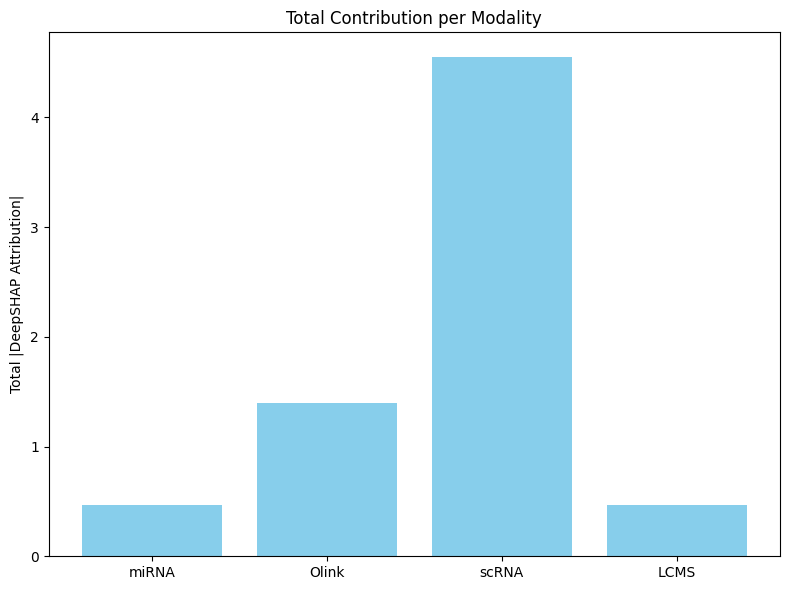

In [15]:
# Define modality names
modality_names = ["miRNA", "Olink", "scRNA", "LCMS"]

# Sum absolute attributions per modality
modality_contributions = [np.sum(np.abs(importance)) for importance in all_feature_importances]

# Plot total contributions
plt.figure(figsize=(8,6))
plt.bar(modality_names, modality_contributions, color='skyblue')
plt.ylabel('Total |DeepSHAP Attribution|')
plt.title('Total Contribution per Modality')
plt.tight_layout()
plt.show()

## Model architecture

In [17]:
from torchinfo import summary

# Provide example inputs for each modality
example_inputs = [torch.randn(1, X.shape[1]) for X in modality_matrices]  # batch size = 1
example_masks  = [torch.randn(1, X.shape[1]) for X in modality_matrices]

summary(model, input_data=(example_inputs, example_masks))


Layer (type:depth-idx)                   Output Shape              Param #
MultiBranchMLP                           [1]                       --
├─ModuleList: 1-1                        --                        --
│    └─MaskedBranch: 2-1                 [1, 8]                    --
│    │    └─Sequential: 3-1              [1, 8]                    5,456
│    └─MaskedBranch: 2-2                 [1, 24]                   --
│    │    └─Sequential: 3-2              [1, 24]                   49,104
│    └─MaskedBranch: 2-3                 [1, 94]                   --
│    │    └─Sequential: 3-3              [1, 94]                   749,368
│    └─MaskedBranch: 2-4                 [1, 8]                    --
│    │    └─Sequential: 3-4              [1, 8]                    1,008
├─Sequential: 1-2                        [1, 1]                    --
│    └─Linear: 2-5                       [1, 32]                   4,320
│    └─ReLU: 2-6                         [1, 32]                   